<a href="https://colab.research.google.com/github/thimotyb/real-world-machine-learning/blob/python3/Forest%2C_Features_and_LightGBM_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimostrazione di valutazione dell'importanza delle feature selezionate nella foresta
## Confronto tra classificazione ad albero singolo, random forest e LightGBM


Import SciKit Tree Library and LightGBM Library

In [1]:
from sklearn import tree
import pandas
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb # Microsoft lightGBM install with: conda install -c conda-forge lightgbm

My functions to do OHE and do feature engineering on Titanic

In [2]:
def cat_to_num(data):
    categories = np.unique(data)
    features = {}
    for cat in categories:
        binary = (data == cat)
        features["%s=%s" % (data.name, cat)] = binary.astype("int")
    return pandas.DataFrame(features)
    
def prepare_data(data):
    """Takes a dataframe of raw data and returns ML model features
    """
    
    # Initially, we build a model only on the available numerical values
    features = data.drop(["PassengerId", "Survived", "Fare", "Name", "Sex", "Ticket", "Cabin", "Embarked"], axis=1)
    
    # Setting missing age values to -1
    features["Age"] = data["Age"].fillna(-1)
    
    # Adding the sqrt of the fare feature
    features["sqrt_Fare"] = np.sqrt(data["Fare"])
    
    # Adding gender categorical value
    features = features.join( cat_to_num(data['Sex']) )
    
    # Adding Embarked categorical value
    features = features.join( cat_to_num(data['Embarked'].fillna("")) )
    
    return features


Load, split, prepare data

In [3]:
data = pandas.read_csv("https://raw.githubusercontent.com/thimotyb/real-world-machine-learning/master/data/titanic.csv")
data_train = data[:int(0.8*len(data))]
data_test = data[int(0.8*len(data)):]
features = prepare_data(data_train)

In [4]:
features

,Pclass,Age,SibSp,Parch,sqrt_Fare,Sex=female,Sex=male,Embarked=,Embarked=C,Embarked=Q,Embarked=S
0,3,22.0,1,0,2.692582,0,1,0,0,0,1
1,1,38.0,1,0,8.442944,1,0,0,1,0,0
2,3,26.0,0,0,2.815138,1,0,0,0,0,1
3,1,35.0,1,0,7.286975,1,0,0,0,0,1
4,3,35.0,0,0,2.837252,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
707,1,42.0,0,0,5.127134,0,1,0,0,0,1
708,1,22.0,0,0,12.310565,1,0,0,0,0,1
709,3,-1.0,1,1,3.904587,0,1,0,1,0,0
710,1,24.0,0,0,7.035922,1,0,0,1,0,0


## First Model: Using a Single Tree Classifier

In [5]:
model = tree.DecisionTreeClassifier(max_depth = 4)
model.fit(features, data_train["Survived"])
print(model.score(prepare_data(data_train), data_train["Survived"]))
model.score(prepare_data(data_test), data_test["Survived"])

0.8117977528089888


0.8212290502793296

## Second Model: Using a Random Forest

In [6]:
from sklearn import ensemble # RF is an ensemble category of model
forest = ensemble.RandomForestClassifier(n_estimators=5000, bootstrap=True, max_features=0.5)
forest.fit(features, data_train["Survived"])
print(forest.score(prepare_data(data_train), data_train["Survived"]))
forest.score(prepare_data(data_test), data_test["Survived"])

0.9817415730337079


0.8268156424581006

Si possono anche richiedere le predizioni in formato probabilistico, per settare la soglia di conversione del falso/vero positivo

In [7]:
forest_predict_proba=forest.predict_proba(prepare_data(data_test))
forest_predict_proba[:20]

array([[0.8402    , 0.1598    ],
       [0.3348    , 0.6652    ],
       [0.91056008, 0.08943992],
       [0.99419333, 0.00580667],
       [0.009     , 0.991     ],
       [0.26511048, 0.73488952],
       [0.9607    , 0.0393    ],
       [0.79371429, 0.20628571],
       [0.00777333, 0.99222667],
       [0.95516   , 0.04484   ],
       [0.32907905, 0.67092095],
       [0.91006008, 0.08993992],
       [0.64      , 0.36      ],
       [0.99301667, 0.00698333],
       [0.2468    , 0.7532    ],
       [0.04219819, 0.95780181],
       [0.75924   , 0.24076   ],
       [0.35093333, 0.64906667],
       [0.0064    , 0.9936    ],
       [0.47113333, 0.52886667]])

Feature importance in the Random Forest

In [8]:
# Elenca e visualizza il ranking delle feature usate nelal foresta
def show_features(forest, X, y):
  importances = forest.feature_importances_

  # Calcola deviazione standard per plottare errore
  std = np.std([tree.feature_importances_ for tree in forest.estimators_],
              axis=0)
  indices = np.argsort(importances)[::-1]

  # Print the feature ranking
  print("Feature ranking:")

  for f in range(X.shape[1]):
      print("%d. feature %s (%f)" % (indices[f], features.columns[indices[f]], importances[indices[f]]))

  # Plot the feature importances of the forest
  plt.figure()
  plt.title("Feature importances")
  plt.bar(range(X.shape[1]), importances[indices],
        color="r", yerr=std[indices], align="center")
  plt.xticks(range(X.shape[1]), indices)
  plt.xlim([-1, X.shape[1]])
  plt.show()
  

Feature ranking:
4. feature sqrt_Fare (0.264369)
1. feature Age (0.233668)
5. feature Sex=female (0.145412)
6. feature Sex=male (0.144695)
0. feature Pclass (0.086549)
2. feature SibSp (0.049097)
3. feature Parch (0.037460)
10. feature Embarked=S (0.016389)
8. feature Embarked=C (0.013342)
9. feature Embarked=Q (0.009005)
7. feature Embarked= (0.000015)


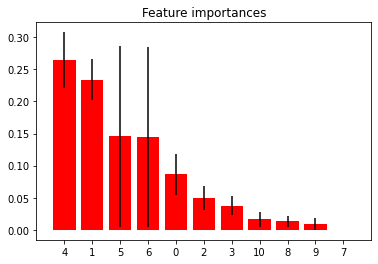

In [9]:
show_features(forest, features, data_train["Survived"])

Mostra gli Stimatori che sono stati usati per comporre la foresta

In [10]:
len(forest.estimators_) # Questo coincide con il numero di stimatori prodotti per popolare la foresta

5000

## Classificazione con una foresta più grande

In [11]:
extraforest = ensemble.ExtraTreesClassifier(n_estimators=100, bootstrap=True)
extraforest.fit(features, data_train["Survived"])
print(extraforest.score(prepare_data(data_train), data_train["Survived"]))
extraforest.score(prepare_data(data_test), data_test["Survived"])

0.9817415730337079


0.8100558659217877

Feature ranking:
4. feature sqrt_Fare (0.237398)
1. feature Age (0.225652)
5. feature Sex=female (0.175398)
6. feature Sex=male (0.115303)
0. feature Pclass (0.104197)
2. feature SibSp (0.055363)
3. feature Parch (0.051095)
10. feature Embarked=S (0.014860)
8. feature Embarked=C (0.012726)
9. feature Embarked=Q (0.007903)
7. feature Embarked= (0.000106)


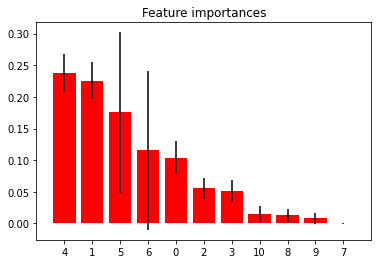

In [12]:
show_features(extraforest, features, data_train["Survived"])

## Classificazione con LightGBM

In [13]:
d_train = lgb.Dataset(features, label=data_train["Survived"])
params = {}
params['learning_rate'] = 0.003
params['boosting_type'] = 'gbdt'
params['objective'] = 'binary'
params['metric'] = 'binary_logloss'
params['sub_feature'] = 0.5
params['num_leaves'] = 10
params['min_data'] = 50
params['max_depth'] = 10
clf = lgb.train(params, d_train, 100)

In [14]:
#Prediction
y_pred=clf.predict(prepare_data(data_test))
pred_proba=clf.predict(prepare_data(data_test))
#convert into binary values

threshold = .45   # setting threshold

for i in range(0,len(y_pred)):
    if y_pred[i]>=threshold:       
       y_pred[i]=1
    else:  
       y_pred[i]=0

In [15]:
data_test["Survived"]
y_pred

array([0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0.])

By definition a confusion matrix  is such that Ci,j is equal to the number of observations known to be in group i but predicted to be in group j.

Thus in binary classification, the count of true negatives is C0,0 , false negatives is C1,0, true positives is C1,1 and false positives is C0,1.

In [16]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(data_test["Survived"], y_pred)
#Accuracy
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_pred,data_test["Survived"])

In [17]:
print("Confusion Matrix:")
print(cm)
print("Model Accuracy: {0}".format(accuracy))

Confusion Matrix:
[[113   2]
 [ 31  33]]
Model Accuracy: 0.8156424581005587


## SHAP Explainer per interpretare i dati dell'ensemble LightGBM

[link text](https://github.com/slundberg/shap)

An excellent book on Interpretable Models, chapter on Shapley Values:
[link text](https://christophm.github.io/interpretable-ml-book/shapley.html#shapley)

SHAP library documentation: https://shap.readthedocs.io/en/latest/index.html

In [18]:
!pip install --upgrade shap
import shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 569 kB 8.3 MB/s 


In [19]:
explainer = shap.TreeExplainer(clf)
prepared_test = prepare_data(data_test)
shap_values = explainer.shap_values(prepared_test)

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


## Visualize a single prediction


In [20]:
# print the JS visualization code to the notebook
shap.initjs()
observation = 0 # Plotta il diagramma di forza dell'osservazione 0 del data set di training
print("Name: {0}".format(data_test.loc[data_test.index[observation],'Name']))
print("Survived: {0}".format(data_test.loc[data_test.index[observation],'Survived']))
print("Predicted: {0}".format(y_pred[observation]))
print("Predicted Proba: {0}".format(pred_proba[observation]))
print("SHAP Score: {0}".format(explainer.expected_value[1]))
print(prepared_test.iloc[observation,:])
shap.force_plot(explainer.expected_value[1], shap_values[1][observation,:], prepared_test.iloc[observation,:])

Name: Taylor, Mr. Elmer Zebley
Survived: 1
Predicted: 0.0
Predicted Proba: 0.3625958580563936
SHAP Score: -0.4520032865881318
Pclass         1.000000
Age           48.000000
SibSp          1.000000
Parch          0.000000
sqrt_Fare      7.211103
Sex=female     0.000000
Sex=male       1.000000
Embarked=      0.000000
Embarked=C     0.000000
Embarked=Q     0.000000
Embarked=S     1.000000
Name: 712, dtype: float64


In [21]:
# visualize the training set predictions
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][:1000,:], prepared_test.iloc[:1000,:])

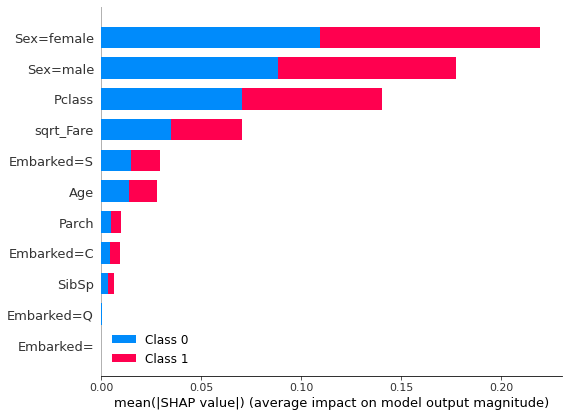

In [22]:
shap.summary_plot(shap_values, prepared_test)

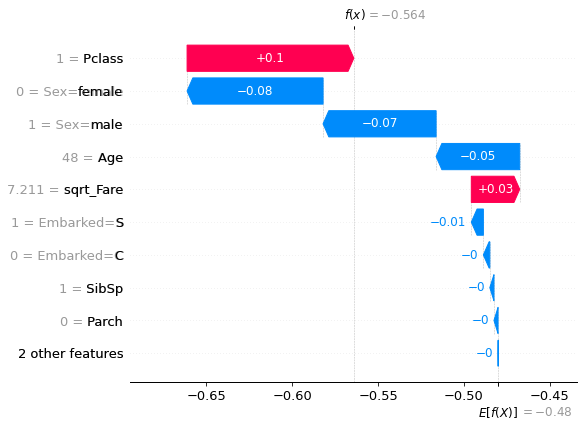

In [25]:
explainer = shap.Explainer(clf, prepared_test)
shap_values = explainer(prepared_test)
shap.plots.waterfall(shap_values[0])